In [82]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.inspection import PartialDependenceDisplay

In [83]:
df = pd.read_csv(r"C:\Users\rossi\Desktop\Saint Joes Files\Machine Learning\GitHubFolder\DSS740_team_4\data\breakfast basket.csv")

In [84]:
print(df.shape)
df.head()

(10248, 27)


,City,Country,ISO_Country_Code,Region,Continent,Month,Month_Name,Item,Item_Key,Item_Category,...,Inflation_Source,FAO_Index_Value,FAO_Index_Date,FAO_YoY_Change_Pct,USDA_All_Food_Forecast_Pct,USDA_Food_At_Home_Pct,Data_Collection_Date,Source_URL,Population_Estimate,Breakfast_Basket_USD
0,New York,United States,USA,North America,North America,2025-10,October 2025,Milk (1 Liter),Milk_1L,Dairy,...,USDA Food Price Outlook / IMF WEO 2026,127.1,October 2025,-1.0,3.1,2.5,2026-03-20,https://www.numbeo.com/food-prices/in/New-York,8336817,16.18
1,New York,United States,USA,North America,North America,2025-11,November 2025,Milk (1 Liter),Milk_1L,Dairy,...,USDA Food Price Outlook / IMF WEO 2026,126.2,November 2025,-1.0,3.1,2.5,2026-03-20,https://www.numbeo.com/food-prices/in/New-York,8336817,16.40
2,New York,United States,USA,North America,North America,2025-12,December 2025,Milk (1 Liter),Milk_1L,Dairy,...,USDA Food Price Outlook / IMF WEO 2026,125.8,December 2025,-1.0,3.1,2.5,2026-03-20,https://www.numbeo.com/food-prices/in/New-York,8336817,17.02
3,New York,United States,USA,North America,North America,2026-01,January 2026,Milk (1 Liter),Milk_1L,Dairy,...,USDA Food Price Outlook / IMF WEO 2026,124.2,January 2026,-1.0,3.1,2.5,2026-03-20,https://www.numbeo.com/food-prices/in/New-York,8336817,16.80
4,New York,United States,USA,North America,North America,2026-02,February 2026,Milk (1 Liter),Milk_1L,Dairy,...,USDA Food Price Outlook / IMF WEO 2026,125.3,February 2026,-1.0,3.1,2.5,2026-03-20,https://www.numbeo.com/food-prices/in/New-York,8336817,16.82


In [85]:
print(df.dtypes)

City                           object
Country                        object
ISO_Country_Code               object
Region                         object
Continent                      object
Month                          object
Month_Name                     object
Item                           object
Item_Key                       object
Item_Category                  object
Quantity                      float64
Unit                           object
Price_Local                   float64
Currency_Local                 object
Price_USD                     float64
Exchange_Rate                 float64
YoY_Inflation_Estimate_Pct    float64
Inflation_Source               object
FAO_Index_Value               float64
FAO_Index_Date                 object
FAO_YoY_Change_Pct            float64
USDA_All_Food_Forecast_Pct    float64
USDA_Food_At_Home_Pct         float64
Data_Collection_Date           object
Source_URL                     object
Population_Estimate             int64
Breakfast_Ba

In [86]:
print(df.isnull().sum())

City                          0
Country                       0
ISO_Country_Code              0
Region                        0
Continent                     0
Month                         0
Month_Name                    0
Item                          0
Item_Key                      0
Item_Category                 0
Quantity                      0
Unit                          0
Price_Local                   0
Currency_Local                0
Price_USD                     0
Exchange_Rate                 0
YoY_Inflation_Estimate_Pct    0
Inflation_Source              0
FAO_Index_Value               0
FAO_Index_Date                0
FAO_YoY_Change_Pct            0
USDA_All_Food_Forecast_Pct    0
USDA_Food_At_Home_Pct         0
Data_Collection_Date          0
Source_URL                    0
Population_Estimate           0
Breakfast_Basket_USD          0
dtype: int64


In [87]:
print(df.duplicated().sum())

0


In [88]:
dfAggregation = df.groupby(['City', 'Country', 'Region', 'Continent', 'Month']).agg(
    Breakfast_Basket_USD=('Breakfast_Basket_USD', 'first'),
    YoY_Inflation_Pct=('YoY_Inflation_Estimate_Pct', 'first'),
    FAO_Index_Value=('FAO_Index_Value', 'first'),
    USDA_All_Food_Forecast_Pct=('USDA_All_Food_Forecast_Pct', 'first'),
    Exchange_Rate=('Exchange_Rate', 'first'),
    Population_Estimate=('Population_Estimate', 'first'),
    Avg_Item_Price_USD=('Price_USD', 'mean')
).reset_index()

print(dfAggregation.shape)
dfAggregation.head()

(732, 12)


,City,Country,Region,Continent,Month,Breakfast_Basket_USD,YoY_Inflation_Pct,FAO_Index_Value,USDA_All_Food_Forecast_Pct,Exchange_Rate,Population_Estimate,Avg_Item_Price_USD
0,Abu Dhabi,United Arab Emirates,MENA,Asia,2025-10,9.18,8.9,127.1,3.1,0.2723,1483000,4.075714
1,Abu Dhabi,United Arab Emirates,MENA,Asia,2025-11,9.34,8.9,126.2,3.1,0.2723,1483000,4.237857
2,Abu Dhabi,United Arab Emirates,MENA,Asia,2025-12,9.51,8.9,125.8,3.1,0.2723,1483000,4.208571
3,Abu Dhabi,United Arab Emirates,MENA,Asia,2026-01,9.30,8.9,124.2,3.1,0.2723,1483000,4.224286
4,Abu Dhabi,United Arab Emirates,MENA,Asia,2026-02,9.53,8.9,125.3,3.1,0.2723,1483000,4.322143


In [89]:
threshold = dfAggregation['YoY_Inflation_Pct'].quantile(0.75)
print(f'Threshold: {threshold}%')

dfAggregation['High_Financial_Pressure'] = (dfAggregation['YoY_Inflation_Pct'] >= threshold).astype(int)
print(dfAggregation['High_Financial_Pressure'].value_counts())

Threshold: 6.5%
High_Financial_Pressure
0    504
1    228
Name: count, dtype: int64


In [90]:
RegionInflation = dfAggregation.groupby('Region')['YoY_Inflation_Pct'].mean().sort_values(ascending=False)
print(RegionInflation)

Region
Sub-Saharan Africa    11.2
North Africa           9.5
MENA                   8.9
Central Asia           7.2
South Asia             6.5
Latin America          5.9
Eastern Europe         5.5
North America          4.3
Southeast Asia         3.8
Oceania                3.5
Western Europe         3.2
East Asia              2.4
Name: YoY_Inflation_Pct, dtype: float64


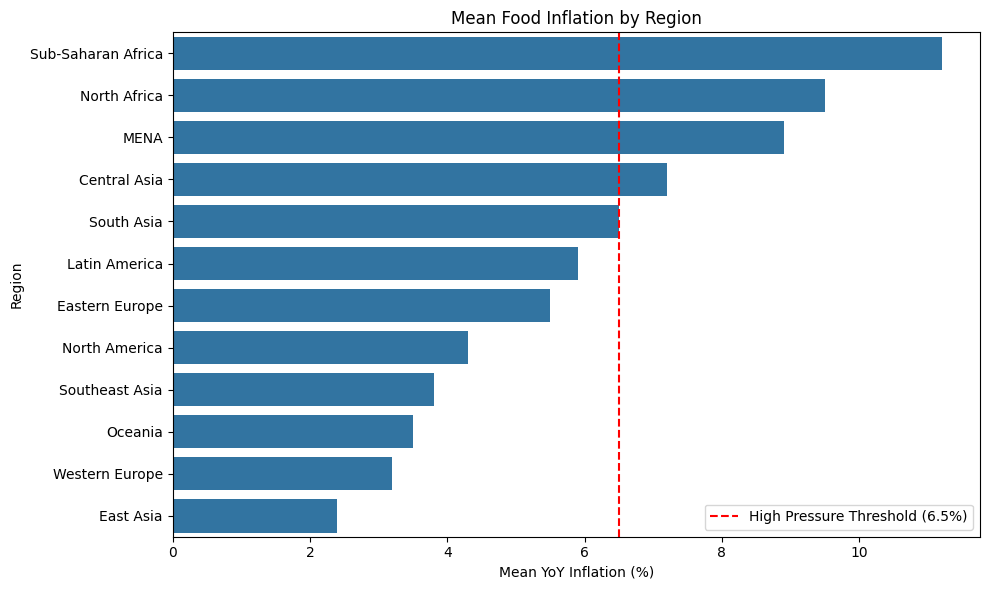

In [91]:
plt.figure(figsize=(10, 6))
sns.barplot(x=RegionInflation.values, y=RegionInflation.index)
plt.axvline(6.5, color='red', linestyle='--', label='High Pressure Threshold (6.5%)')
plt.title('Mean Food Inflation by Region')
plt.xlabel('Mean YoY Inflation (%)')
plt.legend()
plt.tight_layout()
plt.show()

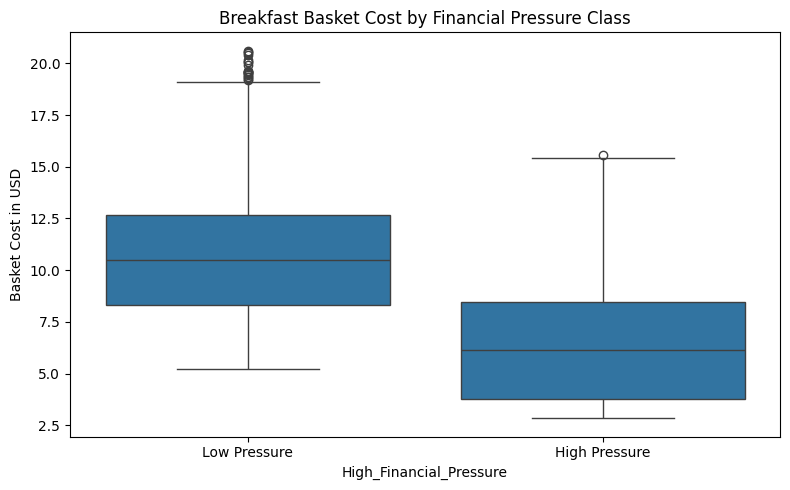

In [92]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='High_Financial_Pressure', y='Breakfast_Basket_USD', data=dfAggregation)
plt.xticks([0, 1], ['Low Pressure', 'High Pressure'])
plt.title('Breakfast Basket Cost by Financial Pressure Class')
plt.ylabel('Basket Cost in USD')
plt.tight_layout()
plt.show()

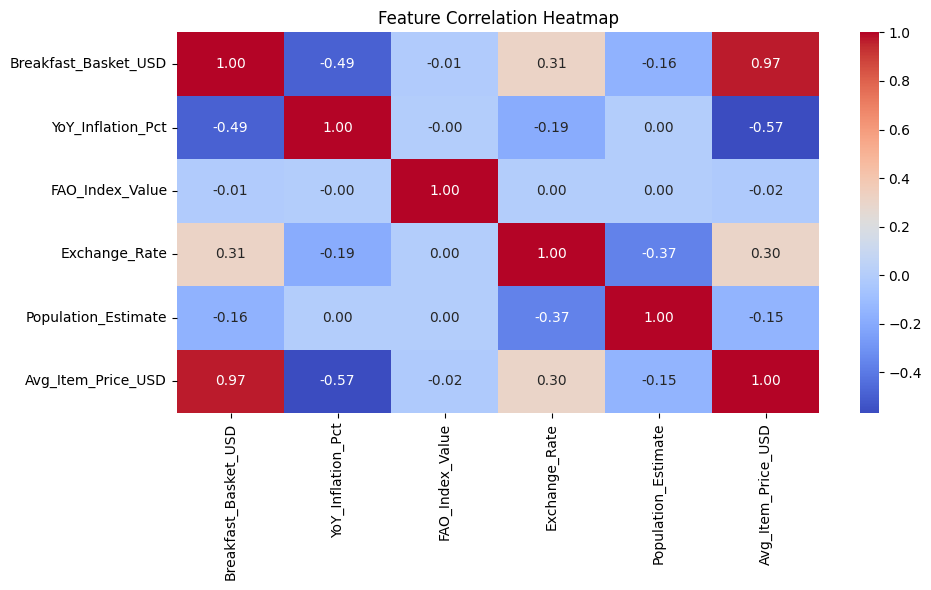

In [93]:
plt.figure(figsize=(10, 6))
numeric_cols = ['Breakfast_Basket_USD', 'YoY_Inflation_Pct', 'FAO_Index_Value',
                'Exchange_Rate', 'Population_Estimate', 'Avg_Item_Price_USD']
sns.heatmap(dfAggregation[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [94]:
LabelEncoder = LabelEncoder()
dfAggregation['Region_Enc'] = LabelEncoder.fit_transform(dfAggregation['Region'])
dfAggregation['Continent_Enc'] = LabelEncoder.fit_transform(dfAggregation['Continent'])


global_mean = dfAggregation['Breakfast_Basket_USD'].mean()
dfAggregation['Basket_vs_Global_Mean'] = dfAggregation['Breakfast_Basket_USD'] / global_mean

dfAggregation['Exchange_Rate_Log'] = np.log1p(dfAggregation['Exchange_Rate'])
dfAggregation['Population_Log'] = np.log1p(dfAggregation['Population_Estimate'])

print(dfAggregation.shape)
dfAggregation.head()

(732, 18)


,City,Country,Region,Continent,Month,Breakfast_Basket_USD,YoY_Inflation_Pct,FAO_Index_Value,USDA_All_Food_Forecast_Pct,Exchange_Rate,Population_Estimate,Avg_Item_Price_USD,High_Financial_Pressure,Region_Enc,Continent_Enc,Basket_vs_Global_Mean,Exchange_Rate_Log,Population_Log
0,Abu Dhabi,United Arab Emirates,MENA,Asia,2025-10,9.18,8.9,127.1,3.1,0.2723,1483000,4.075714,1,4,1,0.959947,0.240826,14.209578
1,Abu Dhabi,United Arab Emirates,MENA,Asia,2025-11,9.34,8.9,126.2,3.1,0.2723,1483000,4.237857,1,4,1,0.976678,0.240826,14.209578
2,Abu Dhabi,United Arab Emirates,MENA,Asia,2025-12,9.51,8.9,125.8,3.1,0.2723,1483000,4.208571,1,4,1,0.994454,0.240826,14.209578
3,Abu Dhabi,United Arab Emirates,MENA,Asia,2026-01,9.30,8.9,124.2,3.1,0.2723,1483000,4.224286,1,4,1,0.972495,0.240826,14.209578
4,Abu Dhabi,United Arab Emirates,MENA,Asia,2026-02,9.53,8.9,125.3,3.1,0.2723,1483000,4.322143,1,4,1,0.996546,0.240826,14.209578


In [95]:
features = ['Breakfast_Basket_USD', 'FAO_Index_Value', 'Exchange_Rate_Log',
            'Population_Log', 'Basket_vs_Global_Mean', 'Region_Enc', 'Continent_Enc']

X = dfAggregation[features]
y = dfAggregation['High_Financial_Pressure']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Training set: {X_train.shape}')
print(f'Test set: {X_test.shape}')

Training set: (585, 7)
Test set: (147, 7)


In [96]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)

print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred):.4f}')
print(f'Recall: {recall_score(y_test, y_pred):.4f}')
print(f'F1 Score: {f1_score(y_test, y_pred):.4f}')

Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000


In [97]:
#well crap

In [98]:
print(f'Tree depth: {dt.get_depth()}')
print(f'Number of leaves: {dt.get_n_leaves()}')

Tree depth: 4
Number of leaves: 9


In [99]:
importances = pd.Series(dt.feature_importances_, index=features).sort_values(ascending=False)
print(importances)

Continent_Enc            0.482301
Region_Enc               0.478853
Population_Log           0.030734
Breakfast_Basket_USD     0.008111
FAO_Index_Value          0.000000
Exchange_Rate_Log        0.000000
Basket_vs_Global_Mean    0.000000
dtype: float64


In [100]:
features = ['Breakfast_Basket_USD', 'FAO_Index_Value', 'Exchange_Rate_Log',
            'Population_Log', 'Basket_vs_Global_Mean']

X = dfAggregation[features]
y = dfAggregation['High_Financial_Pressure']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)

print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred):.4f}')
print(f'Recall: {recall_score(y_test, y_pred):.4f}')
print(f'F1 Score: {f1_score(y_test, y_pred):.4f}')

Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000


In [101]:
#  :(

In [102]:
print(f'Tree depth: {dt.get_depth()}')
print(f'Number of leaves: {dt.get_n_leaves()}')

importances = pd.Series(dt.feature_importances_, index=features).sort_values(ascending=False)
print(importances)

Tree depth: 10
Number of leaves: 18
Exchange_Rate_Log        0.458989
Breakfast_Basket_USD     0.366107
Population_Log           0.109923
Basket_vs_Global_Mean    0.064981
FAO_Index_Value          0.000000
dtype: float64


In [103]:
dt_tuned = DecisionTreeClassifier(max_depth=6, min_samples_leaf=1, min_samples_split=2, random_state=42)
dt_tuned.fit(X_train, y_train)

y_pred_tuned = dt_tuned.predict(X_test)

print(f'Accuracy: {accuracy_score(y_test, y_pred_tuned):.2f}')
print(f'Precision: {precision_score(y_test, y_pred_tuned):.2f}')
print(f'Recall: {recall_score(y_test, y_pred_tuned):.2f}')
print(f'F1 Score: {f1_score(y_test, y_pred_tuned):.2f}')

Accuracy: 0.89
Precision: 0.97
Recall: 0.67
F1 Score: 0.79


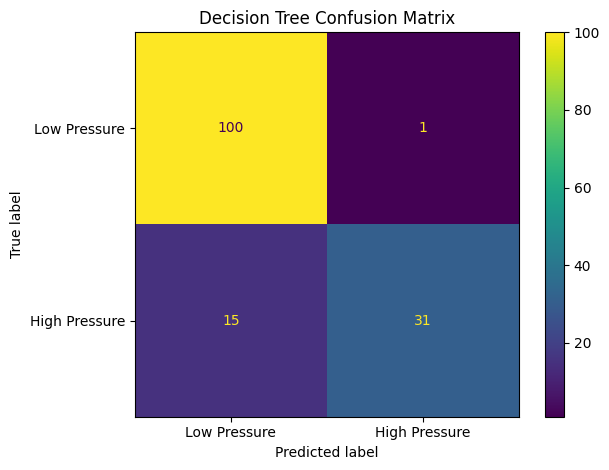

In [104]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tuned, display_labels=['Low Pressure', 'High Pressure'])
plt.title('Decision Tree Confusion Matrix')
plt.tight_layout()
plt.show()

In [105]:
dt_balanced = DecisionTreeClassifier(max_depth=6, min_samples_leaf=1, 
                                      min_samples_split=2, class_weight='balanced', 
                                      random_state=42)
dt_balanced.fit(X_train, y_train)

y_pred_balanced = dt_balanced.predict(X_test)

print(f'Accuracy: {accuracy_score(y_test, y_pred_balanced):.2f}')
print(f'Precision: {precision_score(y_test, y_pred_balanced):.2f}')
print(f'Recall: {recall_score(y_test, y_pred_balanced):.2f}')
print(f'F1 Score: {f1_score(y_test, y_pred_balanced):.2f}')

Accuracy: 0.97
Precision: 1.00
Recall: 0.89
F1 Score: 0.94


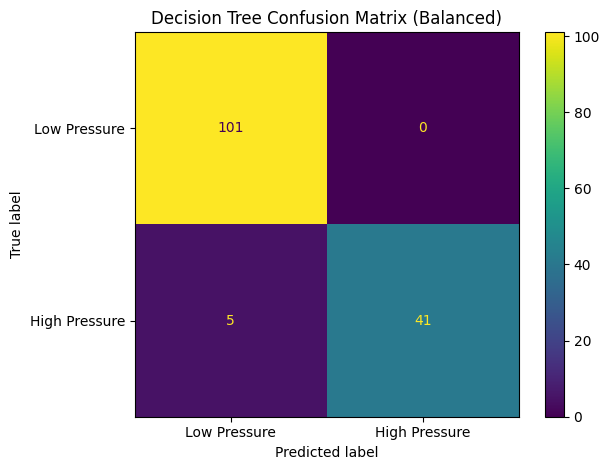

In [106]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_balanced, display_labels=['Low Pressure', 'High Pressure'])
plt.title('Decision Tree Confusion Matrix (Balanced)')
plt.tight_layout()
plt.show()

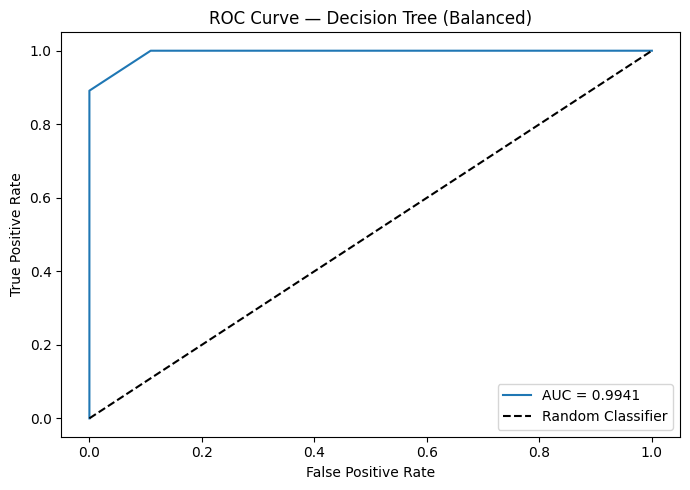

In [107]:
y_prob = dt_balanced.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Decision Tree (Balanced)')
plt.legend()
plt.tight_layout()
plt.show()

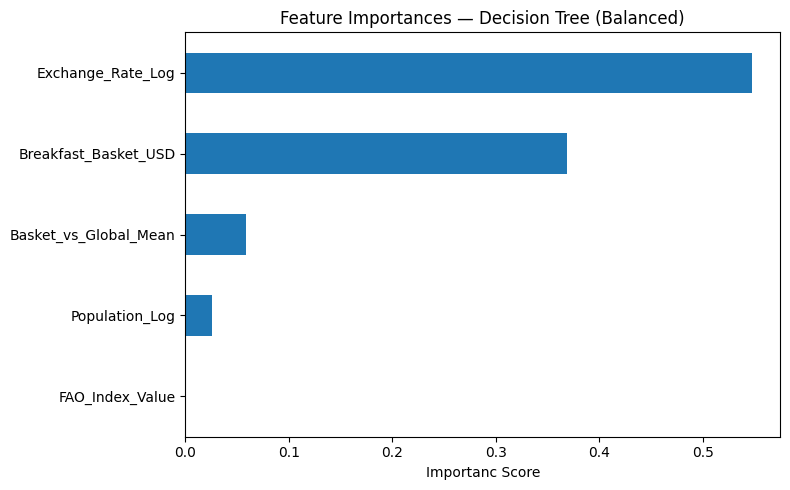

In [108]:
importances = pd.Series(dt_balanced.feature_importances_, index=features).sort_values()

plt.figure(figsize=(8, 5))
importances.plot(kind='barh')
plt.title('Feature Importances — Decision Tree (Balanced)')
plt.xlabel('Importanc Score')
plt.tight_layout()
plt.show()

In [109]:
importances = pd.Series(dt_balanced.feature_importances_, index=features).sort_values(ascending=False)
print(importances.round(4))

Exchange_Rate_Log        0.5472
Breakfast_Basket_USD     0.3690
Basket_vs_Global_Mean    0.0585
Population_Log           0.0252
FAO_Index_Value          0.0000
dtype: float64


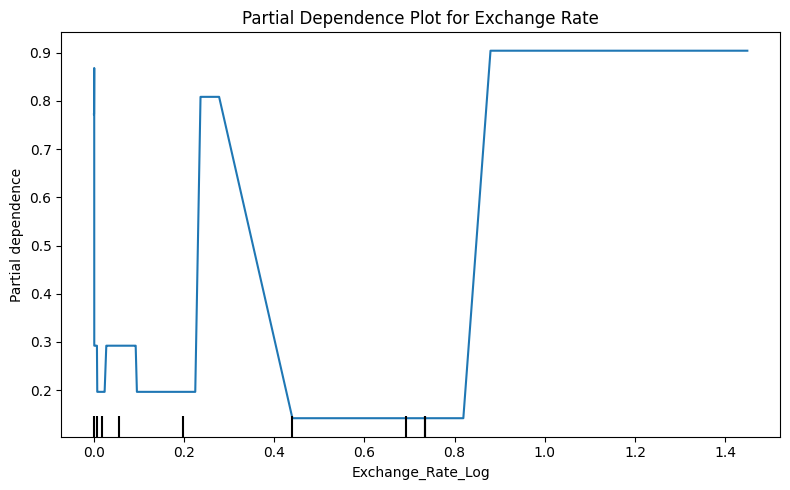

In [110]:
fig, ax = plt.subplots(figsize=(8, 5))
PartialDependenceDisplay.from_estimator(dt_balanced, X_train, features=['Exchange_Rate_Log'], ax=ax)
plt.title('Partial Dependence Plot for Exchange Rate')
plt.tight_layout()
plt.show()

In [111]:
gniData = pd.read_csv(r"C:\Users\rossi\Desktop\Saint Joes Files\Machine Learning\GitHubFolder\DSS740_team_4\Data\GNI.csv")

In [112]:
gni = gniData[['Country Name', '2023']].copy()
gni.columns = ['Country_WB', 'GNI_Per_Capita_2023']
gni = gni.dropna(subset=['GNI_Per_Capita_2023'])

In [113]:
ChangeNamesOfCountries = {
    'Czech Republic': 'Czechia',
    'Russia':         'Russian Federation',
    'Egypt':          'Egypt, Arab Rep.',
    'Turkey':         'Turkiye',        # no accent
    'Iran':           'Iran, Islamic Rep.',
    'South Korea':    'Korea, Rep.',
    'Hong Kong':      'Hong Kong SAR, China',
    'Slovakia':       'Slovak Republic',
    'Vietnam':        'Viet Nam'
}

In [114]:
dfAggregation['Country_WB'] = dfAggregation['Country'].replace(ChangeNamesOfCountries)
dfAggregation = dfAggregation.merge(gni, on='Country_WB', how='left')

In [115]:
print(f"GNI matched: {dfAggregation['GNI_Per_Capita_2023'].notna().sum()} of {len(dfAggregation)} rows")
print(f"Missing GNI for: {dfAggregation[dfAggregation['GNI_Per_Capita_2023'].isna()]['Country'].unique()}")

GNI matched: 726 of 732 rows
Missing GNI for: ['Taiwan']


In [116]:
print(gniData['Country Name'].str.contains('urk', na=False).sum())
print(gniData[gniData['Country Name'].str.contains('urk', na=False)]['Country Name'].values)

print(gniData['Country Name'].str.contains('Taiwan', na=False).sum())
print(gniData[gniData['Country Name'].str.contains('Taiwan', na=False)]['Country Name'].values)

4
['Burkina Faso' 'Turks and Caicos Islands' 'Turkmenistan' 'Turkiye']
0
[]


In [117]:
dfAggregation['Annual_Basket_Cost_USD'] = dfAggregation['Breakfast_Basket_USD'] * 12
dfAggregation['Basket_Pct_Of_GNI'] = (dfAggregation['Annual_Basket_Cost_USD'] / dfAggregation['GNI_Per_Capita_2023']) * 100

print(dfAggregation[['Country', 'City', 'Breakfast_Basket_USD', 'GNI_Per_Capita_2023', 'Basket_Pct_Of_GNI']].sort_values('Basket_Pct_Of_GNI', ascending=False).head(10))

     Country   City  Breakfast_Basket_USD  GNI_Per_Capita_2023  \
365  Nigeria  Lagos                 12.56               2590.0   
363  Nigeria  Lagos                 12.42               2590.0   
364  Nigeria  Lagos                 12.41               2590.0   
362  Nigeria  Lagos                 12.32               2590.0   
11   Nigeria  Abuja                 12.21               2590.0   
10   Nigeria  Abuja                 12.13               2590.0   
9    Nigeria  Abuja                 12.05               2590.0   
360  Nigeria  Lagos                 12.01               2590.0   
7    Nigeria  Abuja                 11.89               2590.0   
361  Nigeria  Lagos                 11.87               2590.0   

     Basket_Pct_Of_GNI  
365           5.819305  
363           5.754440  
364           5.749807  
362           5.708108  
11            5.657143  
10            5.620077  
9             5.583012  
360           5.564479  
7             5.508880  
361           5.499614 

In [118]:
print(dfAggregation[['Country', 'City', 'Breakfast_Basket_USD', 'GNI_Per_Capita_2023', 'Basket_Pct_Of_GNI']].sort_values('Basket_Pct_Of_GNI', ascending=True).head(10))

     Country    City  Breakfast_Basket_USD  GNI_Per_Capita_2023  \
210    Qatar    Doha                 10.21              80200.0   
211    Qatar    Doha                 10.38              80200.0   
213    Qatar    Doha                 10.51              80200.0   
212    Qatar    Doha                 10.71              80200.0   
214    Qatar    Doha                 10.79              80200.0   
215    Qatar    Doha                 10.82              80200.0   
223  Ireland  Dublin                 11.36              79280.0   
222  Ireland  Dublin                 11.42              79280.0   
225  Ireland  Dublin                 11.62              79280.0   
224  Ireland  Dublin                 11.67              79280.0   

     Basket_Pct_Of_GNI  
210           0.152768  
211           0.155312  
213           0.157257  
212           0.160249  
214           0.161446  
215           0.161895  
223           0.171948  
222           0.172856  
225           0.175883  
224         

In [119]:
X_full = dfAggregation[['Breakfast_Basket_USD', 'FAO_Index_Value', 'Exchange_Rate_Log','Population_Log', 'Basket_vs_Global_Mean']]
dfAggregation['Predicted_High_Pressure'] = dt_balanced.predict(X_full)
high_pressure = dfAggregation[dfAggregation['Predicted_High_Pressure'] == 1].copy()
high_pressure_ranked = high_pressure[['Country', 'City', 'Region', 'Breakfast_Basket_USD', 'GNI_Per_Capita_2023', 'Basket_Pct_Of_GNI', 'YoY_Inflation_Pct']].sort_values('Basket_Pct_Of_GNI', ascending=False)

print(f"Total high pressure city-month observations: {len(high_pressure)}")
print(f"Unique high pressure cities: {high_pressure['City'].nunique()}")
print()
print(high_pressure_ranked.head(15).to_string(index=False))

Total high pressure city-month observations: 210
Unique high pressure cities: 35

 Country    City             Region  Breakfast_Basket_USD  GNI_Per_Capita_2023  Basket_Pct_Of_GNI  YoY_Inflation_Pct
 Nigeria   Lagos Sub-Saharan Africa                 12.56               2590.0           5.819305               11.2
 Nigeria   Lagos Sub-Saharan Africa                 12.42               2590.0           5.754440               11.2
 Nigeria   Lagos Sub-Saharan Africa                 12.41               2590.0           5.749807               11.2
 Nigeria   Lagos Sub-Saharan Africa                 12.32               2590.0           5.708108               11.2
 Nigeria   Abuja Sub-Saharan Africa                 12.21               2590.0           5.657143               11.2
 Nigeria   Abuja Sub-Saharan Africa                 12.13               2590.0           5.620077               11.2
 Nigeria   Abuja Sub-Saharan Africa                 12.05               2590.0           5.583012  

In [120]:
high_pressure_summary = high_pressure.groupby(['Country', 'City', 'Region']).agg(Avg_Basket_USD=('Breakfast_Basket_USD', 'mean'),GNI_Per_Capita=('GNI_Per_Capita_2023', 'first'),Avg_Basket_Pct_Of_GNI=('Basket_Pct_Of_GNI', 'mean'),Avg_Inflation_Pct=('YoY_Inflation_Pct', 'mean')).reset_index().sort_values('Avg_Basket_Pct_Of_GNI', ascending=False)

print(high_pressure_summary.head(20).to_string(index=False))

   Country       City             Region  Avg_Basket_USD  GNI_Per_Capita  Avg_Basket_Pct_Of_GNI  Avg_Inflation_Pct
   Nigeria      Lagos Sub-Saharan Africa       12.265000          2590.0               5.682625               11.2
   Nigeria      Abuja Sub-Saharan Africa       11.943333          2590.0               5.533591               11.2
  Pakistan    Karachi         South Asia        3.831667          1450.0               3.171034                6.5
  Pakistan     Lahore         South Asia        3.701667          1450.0               3.063448                6.5
     Nepal  Kathmandu         South Asia        3.640000          1430.0               3.054545                6.5
   Lebanon     Beirut               MENA        9.293333          3700.0               3.014054                8.9
     Kenya    Nairobi Sub-Saharan Africa        4.720000          2110.0               2.684360               11.2
     Kenya    Mombasa Sub-Saharan Africa        4.463333          2110.0        

In [125]:
features_v2 = ['Breakfast_Basket_USD', 'FAO_Index_Value', 'Exchange_Rate_Log',
                'Population_Log', 'Basket_vs_Global_Mean', 
                'Basket_Pct_Of_GNI']

X2 = dfModel[features_v3]
y2 = dfModel['High_Financial_Pressure']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42, stratify=y3)

dt_v2 = DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=42)
dt_v2.fit(X3_train, y3_train)

y2_pred = dt_v2.predict(X3_test)
y2_prob = dt_v2.predict_proba(X3_test)[:, 1]

print(f"Accuracy:  {accuracy_score(y2_test, y2_pred):.4f}")
print(f"Precision: {precision_score(y2_test, y2_pred):.4f}")
print(f"Recall:    {recall_score(y2_test, y2_pred):.4f}")
print(f"F1 Score:  {f1_score(y2_test, y2_pred):.4f}")
print(f"AUC:       {roc_auc_score(y2_test, y2_prob):.4f}")
print(f"\nConfusion Matrix:\n{confusion_matrix(y2_test, y2_pred)}")

importances_v2 = pd.Series(dt_v2.feature_importances_, index=features_v2).sort_values(ascending=False)
print(f"\nFeature Importances:\n{importances_v2.round(4)}")

Accuracy:  0.9178
Precision: 1.0000
Recall:    0.7391
F1 Score:  0.8500
AUC:       0.9765

Confusion Matrix:
[[100   0]
 [ 12  34]]

Feature Importances:
Exchange_Rate_Log        0.4133
Basket_vs_Global_Mean    0.4132
Basket_Pct_Of_GNI        0.1735
Breakfast_Basket_USD     0.0000
FAO_Index_Value          0.0000
Population_Log           0.0000
dtype: float64


In [128]:
comparison = pd.DataFrame({
    'Model': [
        'Baseline (No Depth Limit)', 
        'Tuned (max_depth=6)', 
        'Balanced (max_depth=6, class_weight=balanced)',
        'Final V3 (Balanced + GNI Affordability Ratio)'
    ],
    'Accuracy':  [1.0000, 0.8912, 0.9660, 0.9178],
    'Precision': [1.0000, 0.9688, 1.0000, 1.0000],
    'Recall':    [1.0000, 0.6739, 0.8913, 0.7391],
    'F1 Score':  [1.0000, 0.7949, 0.9425, 0.8500],
    'AUC':       [  None,   None, 0.9941, 0.9765]
})

print(comparison.to_string(index=False))

                                        Model  Accuracy  Precision  Recall  F1 Score    AUC
                    Baseline (No Depth Limit)    1.0000     1.0000  1.0000    1.0000    NaN
                          Tuned (max_depth=6)    0.8912     0.9688  0.6739    0.7949    NaN
Balanced (max_depth=6, class_weight=balanced)    0.9660     1.0000  0.8913    0.9425 0.9941
Final V3 (Balanced + GNI Affordability Ratio)    0.9178     1.0000  0.7391    0.8500 0.9765
